# L2 —— Other 谱系 识别
目标：在L1的Other子集当中，进行细胞类型识别

## 环境与路径

In [2]:
# Code cell
import os, re
import numpy as np
import pandas as pd
import scanpy as sc
import scanpy.external as sce
from scipy.sparse import issparse
import matplotlib.pyplot as plt

# 路径与文件
#DATA_ROOT = "/mnt/c/Users/Future/OneDrive/UC_project/scRNA-seq_data"
DATA_ROOT = "/Users/future/Library/CloudStorage/OneDrive-个人/UC_project/scRNA-seq_data"
ANNO_DIR  = os.path.join(DATA_ROOT, "06_annotation/L2"); os.makedirs(ANNO_DIR, exist_ok=True)
FIG_DIR   = os.path.join(ANNO_DIR, "figs");          os.makedirs(FIG_DIR,  exist_ok=True)

IN_PATH   = os.path.join(DATA_ROOT, "06_annotation/L1/L1_lineage_annotated.h5ad")
OUT_H5AD  = os.path.join(ANNO_DIR, "L2_other_annotated.h5ad")
OUT_CSV   = os.path.join(ANNO_DIR, "L2_other_summary.csv")

## 数据读取 (L1完整数据)

In [3]:
adata = sc.read_h5ad(IN_PATH)
adata

AnnData object with n_obs × n_vars = 374507 × 11743
    obs: 'GSM', 'group', 'GSE', 'leiden_scVI_0.2', 'L1lin_marker', 'L1lin_score', 'L1lin_gpt', 'L1_lineage', 'L1lin_conf'
    var: 'mt'
    uns: 'GSE_colors', 'L1_lineage_colors', 'REFERENCE_MANU', 'leiden_scVI_0.2', 'leiden_scVI_0.2_colors', 'log1p', 'neighbors', 'rank_genes_groups', 'umap'
    obsm: 'X_scVI', 'X_umap'
    layers: 'counts'
    obsp: 'connectivities'

/Users/future/miniconda3/envs/scanpy/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/Users/future/miniconda3/envs/scanpy/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/Users/future/miniconda3/envs/scanpy/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(

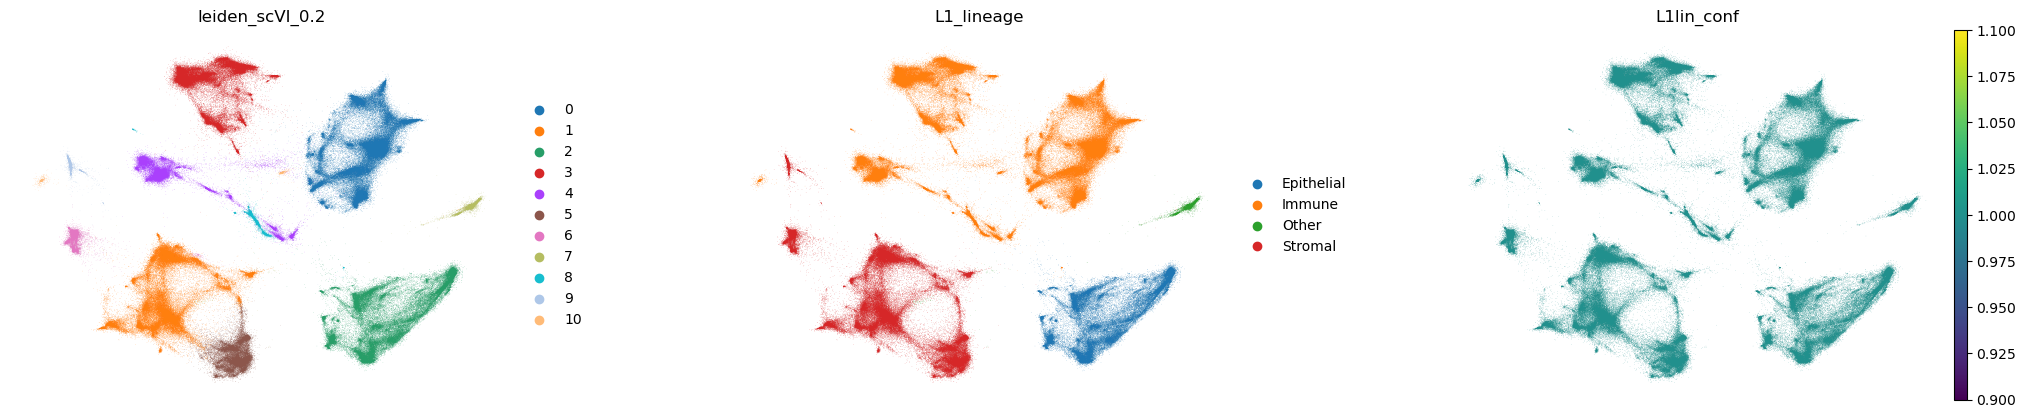

In [4]:
# UMAP
sc.pl.umap(adata, color=["leiden_scVI_0.2", "L1_lineage", 'L1lin_conf'],
           wspace=0.3, frameon=False)

/Users/future/miniconda3/envs/scanpy/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/Users/future/miniconda3/envs/scanpy/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


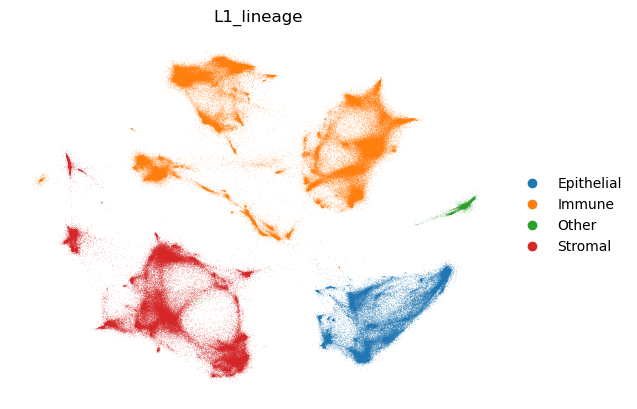

In [7]:
sc.pl.umap(adata, color=["L1_lineage"], frameon=False)

## 可能细胞类型推断
- 神经系统：
    - 肠道神经元
    - 肠道神经胶质

In [15]:
cand_neuro = [
    # 神经元相关
    "TUBB3","STMN2","DCX","NEFL","SNAP25","SYT1","SYN1","RBFOX3",
    # 神经胶质相关
    "SOX10","PLP1","MOBP","GFAP","AQP4","CLDN11","FABP7",
    "S100B","MPZ","GPM6B",
]

[g for g in cand_neuro if g in adata.var_names]

['S100B', 'MPZ', 'GPM6B']

表达矩阵当中神经谱系的marker基因非常少

### 在UMAP上直接看marker表达

/Users/future/miniconda3/envs/scanpy/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/Users/future/miniconda3/envs/scanpy/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


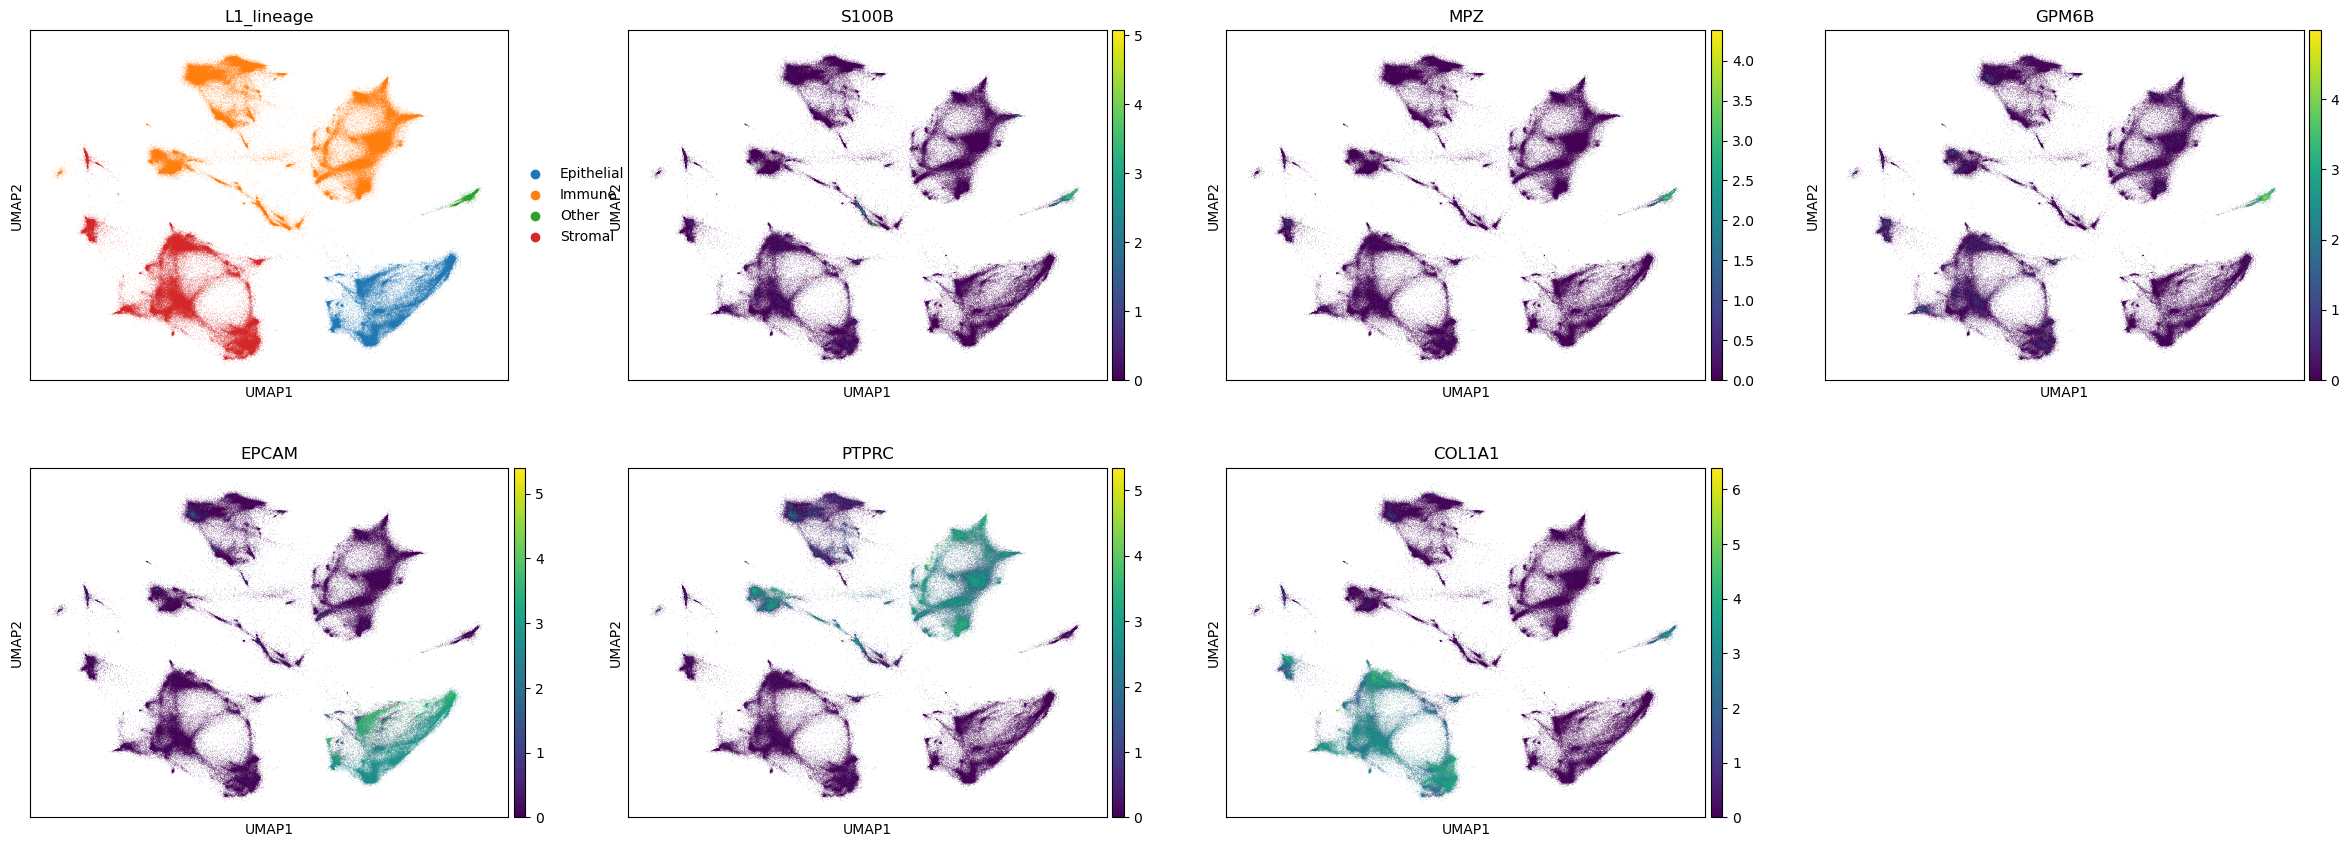

In [16]:
panel = ["S100B","MPZ","GPM6B",
         "EPCAM", "PTPRC","COL1A1"]

panel = [g for g in panel if g in adata.var_names]

import scanpy as sc
sc.pl.umap(
    adata,
    color=["L1_lineage"] + panel,
    ncols=4
)

### 评分查看marker在四个谱系上的分布

/Users/future/miniconda3/envs/scanpy/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:840: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/Users/future/miniconda3/envs/scanpy/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:840: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(


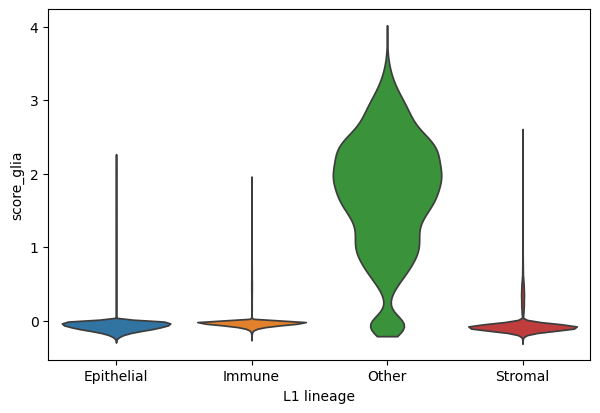

/Users/future/miniconda3/envs/scanpy/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/Users/future/miniconda3/envs/scanpy/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


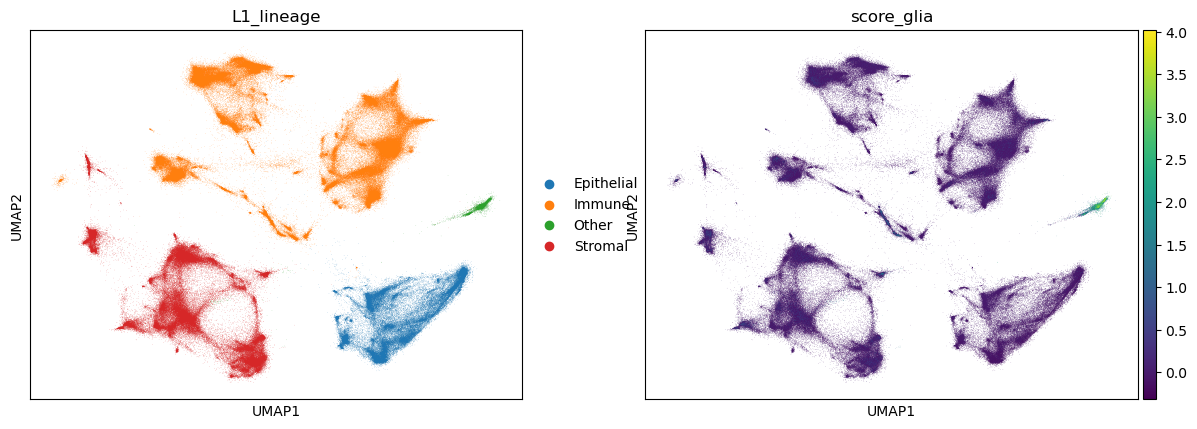

In [17]:
glia_genes = [g for g in ["S100B","MPZ","GPM6B"] if g in adata.var_names]

import scanpy as sc
sc.tl.score_genes(
    adata,
    gene_list=glia_genes,
    score_name="score_glia"
)

sc.pl.violin(
    adata,
    keys="score_glia",
    groupby="L1_lineage",
    stripplot=False
)

sc.pl.umap(
    adata,
    color=["L1_lineage","score_glia"],
    ncols=2
)

In [19]:
import numpy as np

adata.obs["Other_vs_rest"] = (
    adata.obs["L1_lineage"]
    .eq("Other")
    .map({True: "Other", False: "Rest"})
    .astype("category")
)

sc.tl.rank_genes_groups(
    adata,
    groupby="Other_vs_rest",
    groups=["Other"],
    reference="Rest",
    method="wilcoxon"
)

sc.pl.rank_genes_groups(
    adata,
    groups=["Other"],
    n_genes=30,
    sharey=False
)

/Users/future/miniconda3/envs/scanpy/lib/python3.10/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


KeyboardInterrupt: 